|<h2>Course:</h2>|<h1><a href="https://derivingsystems.com/course.html" target="_blank">Build your own vLLM: inference engines from the memory system up</a></h1>|
|-|:-:|
|<h2>Part 3:</h2>|<h1>PagedAttention<h1>|
|<h2>Section:</h2>|<h1>The block allocator<h1>|
|<h2>Lecture:</h2>|<h1><b>A page table for tokens: the 1961 fix<b></h1>|

<br>

<h5><b>Course repo:</b> <a href="https://github.com/Venugopalan2610/vllm-from-scratch" target="_blank">github.com/Venugopalan2610/vllm-from-scratch</a></h5>
<h5><b>The derivations:</b> <a href="https://derivingsystems.com" target="_blank">derivingsystems.com</a></h5>
<i>The notebooks build the intuition. The ladder in app/ makes you build the thing.</i>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

rng = np.random.default_rng(0)

# A page table for tokens

Cut the pool into fixed **blocks** of 16 tokens. Give out one block at a time,
as a sequence grows. Keep one **block table** per sequence. The table says
which physical block holds which logical position.

That is all of PagedAttention. The table below shows why it works.

In [2]:
# The KV cost per token is arithmetic about the MODEL, not a magic number.
# Two entries (K and V), one per layer, per KV head, per element of head_dim.
LAYERS, KV_HEADS, HEAD_DIM, DTYPE_BYTES = 28, 8, 128, 2      # Qwen3-0.6B, bf16
KV_BYTES = 2 * LAYERS * KV_HEADS * HEAD_DIM * DTYPE_BYTES

lengths = rng.lognormal(mean=np.log(120), sigma=0.9, size=20000).astype(int) + 1
POOL_BYTES = 10e9              # bytes of VRAM left after the weights

print(f'{KV_BYTES/1024:.0f} KB per token, {POOL_BYTES/1e9:.0f} GB of pool')
print(f'median output {np.median(lengths):.0f} tokens, p99 {np.percentile(lengths,99):.0f}')

112 KB per token, 10 GB of pool
median output 120 tokens, p99 960


| operating system | vLLM |
|---|---|
| process | sequence |
| page, 4 KB | block, 16 tokens of KV |
| page table | block table |
| physical frame | physical block in the pool |
| virtual address | logical token position |
| internal fragmentation | at most one partial block |
| [copy-on-write](../../GLOSSARY.md#copy-on-write) after fork | copy-on-write when samples diverge |
| page cache | automatic prefix caching |
| swapping | swap blocks to CPU under pressure |

Each row on the right is a stage in this course. None of the ideas are new.
Only their use on a KV cache is new.

### What the cache costs now

In [3]:
BLOCK_SIZE = 16

sample = rng.choice(lengths, 20000)
blocks_per_sequence = np.ceil(sample / BLOCK_SIZE)
paged_bytes = blocks_per_sequence * BLOCK_SIZE * KV_BYTES

print(f'block size {BLOCK_SIZE} tokens = {BLOCK_SIZE*KV_BYTES/1e6:.1f} MB')
print(f'average sequence holds {blocks_per_sequence.mean():.1f} blocks ({paged_bytes.mean()/1e6:.0f} MB)')
paged_tokens = blocks_per_sequence * BLOCK_SIZE        # tokens of room held, not bytes
print(f'\nwaste: {100*(1 - sample.sum()/paged_tokens.sum()):.1f}%')
print(f'  and it can never exceed {BLOCK_SIZE-1} tokens per sequence, whatever the workload')

block size 16 tokens = 1.8 MB
average sequence holds 11.7 blocks (22 MB)

waste: 4.0%
  and it can never exceed 15 tokens per sequence, whatever the workload


In [4]:
MAX_LEN = 2048
contiguous = POOL_BYTES / (MAX_LEN * KV_BYTES)
paged = POOL_BYTES / paged_bytes.mean()

print(f'contiguous, reserving {MAX_LEN}: {contiguous:6.0f} sequences resident')
print(f'paged, blocks of {BLOCK_SIZE}:        {paged:6.0f} sequences resident')
print(f'\n{paged/contiguous:.1f}x more users on the same card, for no new arithmetic')

# Now look at the parts of that ratio:
#
#   paged      POOL / (blocks x BLOCK x KV)      MAX_LEN
#   -------  = ----------------------------  = -----------------
#   contig     POOL / (MAX_LEN x KV)            blocks x BLOCK
#
# POOL cancels and KV cancels. The win does not depend on how much VRAM you
# have or which model you run. It depends only on how pessimistic max_len was
# against how long the replies actually are.
print(f'\nthe same ratio, without the card or the model in it: '
      f'{MAX_LEN/(blocks_per_sequence.mean()*BLOCK_SIZE):.1f}x')

contiguous, reserving 2048:     43 sequences resident
paged, blocks of 16:           464 sequences resident

10.9x more users on the same card, for no new arithmetic

the same ratio, without the card or the model in it: 10.9x


### Choose the block size

Small blocks waste less memory and cost more bookkeeping. Large blocks do the
opposite. Most engines use 16. Here is the reason.

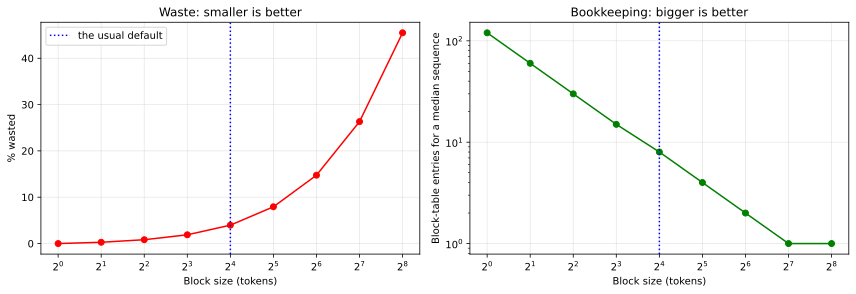

block    1:   0.0% wasted,   120 table entries for a median sequence
block   16:   4.0% wasted,     8 table entries for a median sequence
block  256:  45.5% wasted,     1 table entries for a median sequence


In [5]:
block_sizes = np.array([1,2,4,8,16,32,64,128,256])
waste_fractions = np.array([1 - sample.sum()/(np.ceil(sample/block_size)*block_size).sum() for block_size in block_sizes])
lookups = np.ceil(np.median(sample)/block_sizes)

fig, axes = plt.subplots(1,2, figsize=(12,4.2))
axes[0].plot(block_sizes, 100*waste_fractions, 'ro-')
axes[0].axvline(16, color='b', ls=':', label='the usual default')
axes[0].set_xscale('log', base=2)
axes[0].set(xlabel='Block size (tokens)', ylabel='% wasted',
           title='Waste: smaller is better')
axes[0].legend()
axes[0].grid(alpha=.3)

axes[1].plot(block_sizes, lookups, 'go-')
axes[1].axvline(16, color='b', ls=':')
axes[1].set_xscale('log', base=2)
axes[1].set_yscale('log')
axes[1].set(xlabel='Block size (tokens)',
           ylabel='Block-table entries for a median sequence',
           title='Bookkeeping: bigger is better')
axes[1].grid(alpha=.3)
plt.tight_layout()
plt.show()

for block_size in (1, 16, 256):
  print(f'block {block_size:>4}: {100*(1 - sample.sum()/(np.ceil(sample/block_size)*block_size).sum()):5.1f}% wasted, '
        f'{np.ceil(np.median(sample)/block_size):5.0f} table entries for a median sequence')

### What paging costs somewhere else

Nothing is free. Attention can no longer stride a contiguous tensor. The
kernel must walk the block table and gather K and V.

PagedAttention needed a custom kernel for this reason. It could not call
FlashAttention. Stage 07 shows you the slowdown in PyTorch. Stages 08 to 08c
make you recover it.

    ./vc guide 6